In [1]:
import pandas as pd

In [2]:
hr = pd.read_csv(r"HR-Employee-Attrition.csv")
hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# import necessary libraries for MySQL connection

import mysql.connector
from sqlalchemy import create_engine

In [16]:
# Create a connection to the MySQL database
engine = create_engine('mysql+mysqlconnector://root:@localhost/hr_analytics') 

# Load data into MySQL
hr.to_sql('employees', con=engine, if_exists='replace', index=False)

print("Data loaded successfully into MySQL")

Data loaded successfully into MySQL


In [18]:
# Verify the data loaded correctly

print(f"Dataset Shape: {hr.shape}")
print(f"\nColumns: {hr.columns.tolist()}")
print(f"\nMissing Values:\n{hr_copy.isnull().sum()}")
print(f'\nData Types:\n{hr.dtypes}')

Dataset Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
Age                            0
Attrition                   1470
BusinessTravel                 0
DailyRate                      0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
EmployeeCount                  0
EmployeeNumber                 

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


In [63]:
# Data Preparation

def prepare_data(hr):

    # Create a copy of the original dataframe
    hr_copy = hr.copy()
    hr_copy['Attrition'] = hr_copy['Attrition'].astype('category')
    
    # Converting Attrition to Binary
    hr_copy['Attrition'] = hr_copy['Attrition'].map({'Yes':1, 'No':0})    

    # Encoding Categorical Variables
    categorical_cols = hr_copy.select_dtypes(include=['object']).columns

    label_encoder = {}
    for col in categorical_cols:
        le = LabelEncoder()
        hr_copy[col] = le.fit_transform(hr_copy[col])
        label_encoder = le 

    return hr_copy    

# Prepare data

hr_copy = prepare_data(hr)


 === EXLORATORY DATA ANALYSIS ===

1. Overal Attrition Rate :
 nan%

2. top 10 features correlated with attrition:
Age                NaN
Attrition          NaN
BusinessTravel     NaN
DailyRate          NaN
Department         NaN
DistanceFromHome   NaN
Education          NaN
EducationField     NaN
EmployeeCount      NaN
EmployeeNumber     NaN
Name: Attrition, dtype: float64


ValueError: List of boxplot statistics and `positions` values must have same the length

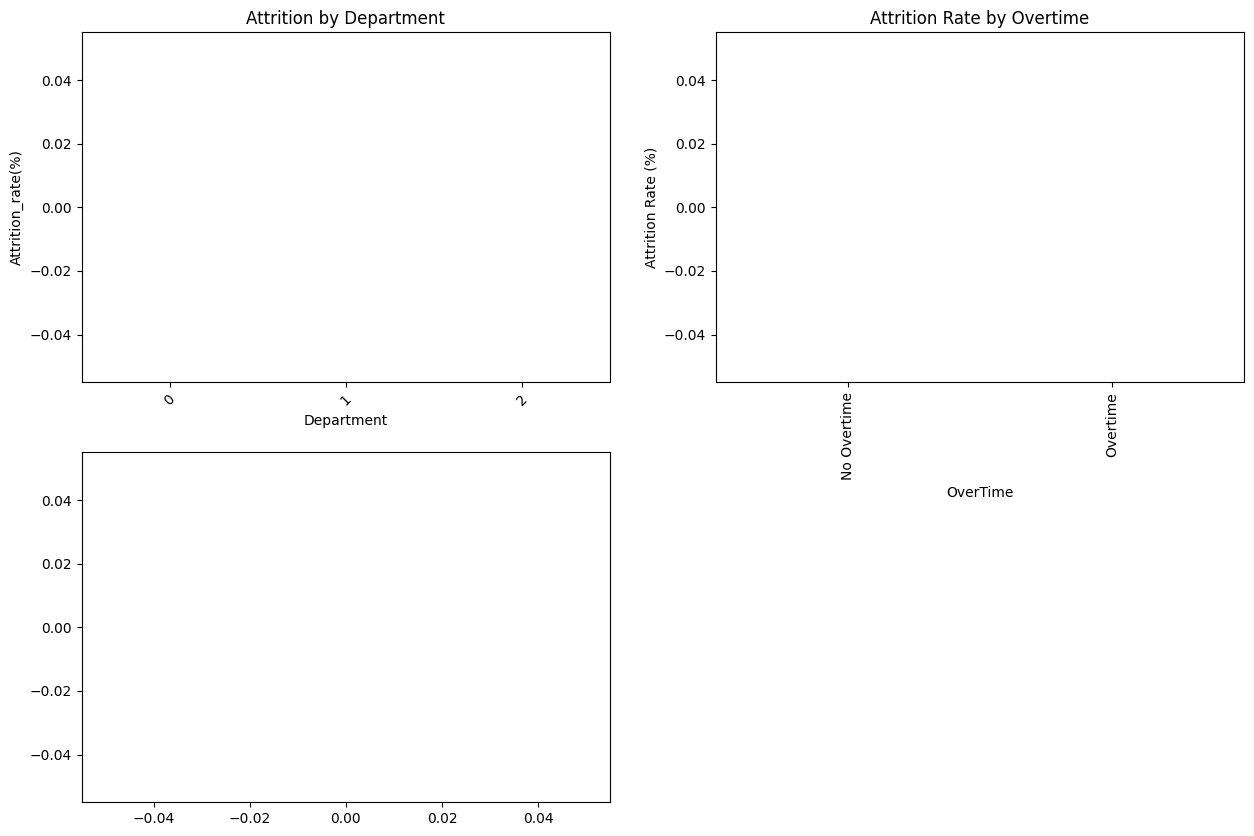

In [64]:
# Exploratory Data Analysis

def perform_eda(hr_copy):
    print(' === EXLORATORY DATA ANALYSIS ===')

    #1. Attrition Destributrion

    attrition_rate = hr_copy['Attrition'].mean() * 100
    print(f"\n1. Overal Attrition Rate :\n {attrition_rate:.2f}%")

    #2. Correlation with attrition

    numeric_cols = hr_copy.select_dtypes(include=[np.number]).columns
    correlation = hr_copy[numeric_cols].corr()['Attrition'].sort_values(ascending=False)
    print(f'\n2. top 10 features correlated with attrition:\n{correlation.head(10)}')

    #3. visualization

    plt.figure(figsize=(15, 10)) 

    #subplot 1: Attrition by Department

    plt.subplot(2, 2, 1)
    dept_attrition = hr_copy.groupby('Department')['Attrition'].mean() * 100
    dept_attrition.plot(kind = 'bar', color='skyblue')
    plt.title('Attrition by Department')
    plt.ylabel('Attrition_rate(%)')    
    plt.xticks(rotation = 45)

    # subplot 2: Attrition by Over time

    plt.subplot(2, 2, 2)
    overtime_attrition = hr_copy.groupby('OverTime')['Attrition'].mean() * 100
    overtime_attrition.plot(kind='bar', color='lightcoral')
    plt.title('Attrition Rate by Overtime')
    plt.ylabel('Attrition Rate (%)')
    plt.xticks([0, 1], ['No Overtime', 'Overtime'])


    # subplot 3: Income vs Attrition
    
    plt.subplot(2, 2, 3)
    sns.boxplot(x='Attrition', y='MonthlyIncome', data = hr_copy)
    plt.title('Monthly Income vs Attrition')
    plt.xlabel('Attrition (0=No, 1=Yes)')
    plt.ylabel('Monthly Income')

    # Subplot 4: Job Satisfaction

    plt.subplot(2, 2, 4)
    satisfaction_attrition = hr_copy.groupby('JobSatisfaction')['Attrition'].mean() * 100
    satisfaction_attrition.plot(kind='line', marker='o', color='green')
    plt.title('Attrition Rate by Job Satisfaction')
    plt.xlabel('Job Satisfaction (1-4)')
    plt.ylabel('Attrition Rate (%)')

    plt.tight_layout()
    plt.show()

    return correlation

# run EDA

correlation = perform_eda(hr_copy)

In [35]:
hr_copy.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')